Create diagrams that demonstrate 
1. the size of genomes, number of chromosomes (scatter plot)
2. the BUSCO and gaps per MB characteristics

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [26]:
metadata_path = "data/tables/metadata_with_longistaminata.tsv"
metadata = pd.read_csv(metadata_path, sep="\t", header=1)

colnames=['Order',
 'Species',
 'Chromosome_number_(n)',
 'Assembly_size_(Mb)',
 'Chromosome_size_(Mb)',
 'Chromosomes_in_analysis',
 'Assembly_size_in_analysis_(Mb)',
 'Accession',
 'Family',
 'Centromere_architecture',
 'Included_chromosomes',
 'Gaps_per_chr',
 'Gaps_per_Mb',
 'Busco_pct']
metadata.columns = colnames



In [27]:
from matplotlib import font_manager
import matplotlib

# Add fonts from the new directory to matplotlib
custom_fonts_path = "config/fonts"
custom_fonts = font_manager.findSystemFonts(fontpaths=custom_fonts_path, fontext='ttf')
for font in custom_fonts:
    try:
        font_manager.fontManager.addfont(font)
    except Exception as e:
        print(f"Skipping font {font} due to error: {e}")


matplotlib.rcParams['font.family'] = "sans-serif"
matplotlib.rcParams['font.sans-serif'] = "Arial"



In [28]:
palette = {"Convolvulaceae": "#f3b674", "Poaceae": "#a6f3a6", "Juncaceae": "#ff41c8", "Cyperaceae": "#916f6f", "Melanthiaceae": "#37abc8"}
shape = {"holocentric": "^", "monocentric": "o"}

In [29]:
# transform genome size to log10
metadata["Log_Assembly_size_(Mb)"] = metadata["Assembly_size_(Mb)"].apply(lambda x: x if x <= 0 else np.log10(x))

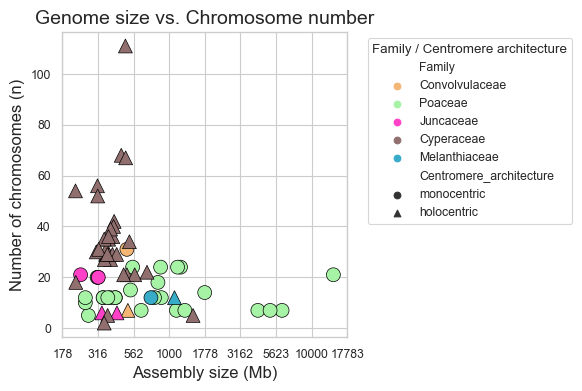

In [30]:
import numpy as np

sns.set_theme(context="paper", style="whitegrid")
plt.figure(figsize=(6, 4))
ax = sns.scatterplot(
    data=metadata,
    x="Log_Assembly_size_(Mb)",
    y="Chromosome_number_(n)",
    hue="Family",
    style="Centromere_architecture",
    palette=palette,
    markers=shape,
    s=100,
    edgecolor="black",      # black outlines
    linewidth=0.5
)

# Back-transform x-axis ticks (log10 → original Mb values)
xticks = ax.get_xticks()
ax.set_xticks(xticks)
ax.set_xticklabels([f"{10**x:.0f}" for x in xticks])

plt.xlabel("Assembly size (Mb)", fontsize=12)
plt.ylabel("Number of chromosomes (n)", fontsize=12)
plt.title("Genome size vs. Chromosome number", fontsize=14)
plt.legend(title="Family / Centromere architecture", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("data/figures/genome_size_vs_chromosome_number.svg", dpi=300, format="svg")



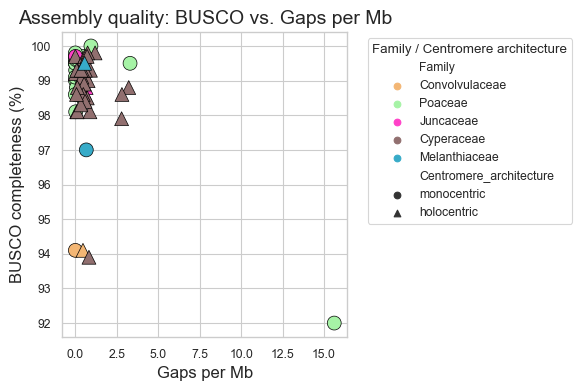

In [32]:
# plotting BUSCO completeness vs. Gaps per Mb
plt.figure(figsize=(6, 4))
ax = sns.scatterplot(
    data=metadata,
    x="Gaps_per_Mb",
    y="Busco_pct",
    hue="Family",
    style="Centromere_architecture",
    palette=palette,
    markers=shape,
    s=100,
    edgecolor="black",      # black outlines
    linewidth=0.5
)
plt.xlabel("Gaps per Mb", fontsize=12)
plt.ylabel("BUSCO completeness (%)", fontsize=12)
plt.title("Assembly quality: BUSCO vs. Gaps per Mb", fontsize=14)
plt.legend(title="Family / Centromere architecture", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("data/figures/busco_vs_gaps_per_mb.svg", dpi=300, format="svg")